### Imports

In [1]:
import warnings

import torch

from src.config import CONFIG
from src.run_train import train_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.CNN
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

Loading 30000 spectrograms...


[I 2026-03-25 16:01:33,874] A new study created in memory with name: no-name-13f2d6b5-fc0f-4d63-9c88-ee8729da6667


Finished loading spectrograms.
Running hyperparameter sweep...


[I 2026-03-25 16:02:07,808] Trial 0 finished with value: 99.33333333333333 and parameters: {'lr': 0.0006554224222261126}. Best is trial 0 with value: 99.33333333333333.
[I 2026-03-25 16:02:14,025] Trial 1 finished with value: 98.2 and parameters: {'lr': 0.005144970295138117}. Best is trial 0 with value: 99.33333333333333.
[I 2026-03-25 16:02:20,125] Trial 2 finished with value: 97.7 and parameters: {'lr': 0.007456898208253735}. Best is trial 0 with value: 99.33333333333333.
[I 2026-03-25 16:02:26,371] Trial 3 finished with value: 99.03333333333333 and parameters: {'lr': 0.002387636530728888}. Best is trial 0 with value: 99.33333333333333.
[I 2026-03-25 16:02:32,296] Trial 4 finished with value: 96.36666666666666 and parameters: {'lr': 0.00013461848337757514}. Best is trial 0 with value: 99.33333333333333.
[I 2026-03-25 16:02:33,507] Trial 5 pruned. 
[I 2026-03-25 16:02:34,691] Trial 6 pruned. 
[I 2026-03-25 16:02:35,861] Trial 7 pruned. 
[I 2026-03-25 16:02:40,633] Trial 8 pruned. 
[I 

Hyperparameter sweep completed.
Accuracy: 99.37%
Parameters: {'lr': 0.0011852720794458629}


### Training

Loading 30000 spectrograms...
Finished loading spectrograms.
Hyperparameters used: {'lr': 0.0011852720794458629, 'model_init': {}}

Training CNN...
[Epoch 1/50]
Train Loss: 0.82 | Train Accuracy: 73.37% | Val Loss: 0.11 | Val Accuracy: 97.07%
Epoch Duration: 24s | Total Time Elapsed: 24s

[Epoch 2/50]
Train Loss: 0.12 | Train Accuracy: 96.51% | Val Loss: 0.05 | Val Accuracy: 98.63%
Epoch Duration: 1s | Total Time Elapsed: 25s

[Epoch 3/50]
Train Loss: 0.07 | Train Accuracy: 97.85% | Val Loss: 0.03 | Val Accuracy: 99.20%
Epoch Duration: 1s | Total Time Elapsed: 27s

[Epoch 4/50]
Train Loss: 0.06 | Train Accuracy: 98.31% | Val Loss: 0.03 | Val Accuracy: 99.10%
Epoch Duration: 1s | Total Time Elapsed: 28s

[Epoch 5/50]
Train Loss: 0.04 | Train Accuracy: 98.62% | Val Loss: 0.03 | Val Accuracy: 99.20%
Epoch Duration: 1s | Total Time Elapsed: 29s

[Epoch 6/50]
Train Loss: 0.04 | Train Accuracy: 98.82% | Val Loss: 0.02 | Val Accuracy: 99.47%
Epoch Duration: 1s | Total Time Elapsed: 30s

[Epoc

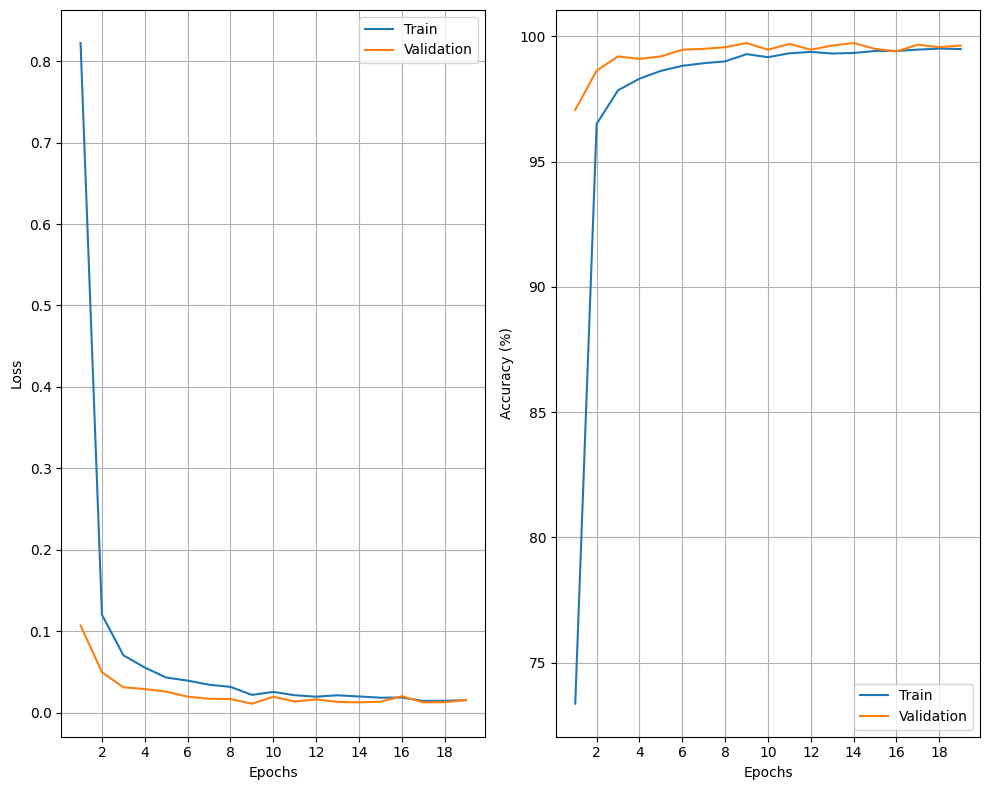

In [5]:
results = train_and_benchmark(device, MODEL, DATASET, FILTERBANK)
plot_training_history(**results['epoch_history'])